In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
runs = 100
x = np.zeros((runs,10))
y = np.zeros((runs,10))

## No interaction between particles

In [6]:
delta = 0.01
for i in range(runs-1):
    x[i+1,:] = x[i,:] + np.sqrt(2)*delta*np.random.normal(0, 1,(10))
    y[i+1,:] = y[i,:] + np.sqrt(2)*delta*np.random.normal(0, 1,(10))

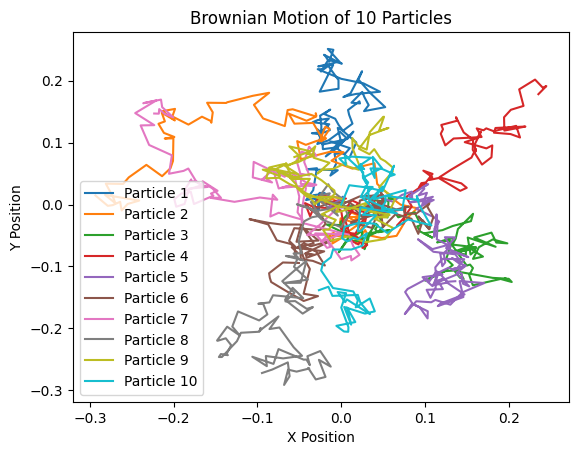

In [11]:
for n in range(10):
    plt.plot(x[:,n], y[:,n], label=f"Particle {n+1}")
plt.title("Brownian Motion of 10 Particles")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()

## Lennard Jones interaction between particles

In [89]:
epsilon = 1.0
sigma = 1.0

def is_valid(x,y):
    for i in range(10):
        for j in range(10):
            if i == j:
                continue
            if abs((x[i] - x[j])**2 + (y[i] - y[j])**2) < 1:
                print(f"Particles {i+1} and {j+1} are too close!")
                print(x[i], y[i])
                print(x[j], y[j])
                return False
    return True

def grad(x):
    '''x is a (10,) matrix'''
    out = 0
    for i in range(10):
        for j in range(10):
            if i == j:
                continue
            if x[i] == x[j]:
                continue
            dir = (x[i] - x[j])/np.linalg.norm(x[i] - x[j])
            out += dir * grad1(np.linalg.norm(x[i] - x[j]))
    return out

def grad1(x):
    return 24* (epsilon/(sigma*4.11e-21)) * (np.power(x,-6) - 2 * np.power(x,-12))

In [92]:
x = np.zeros((runs,10))
y = np.zeros((runs,10))
# particles = np.array([
#     [0,0],
#     [0,1],
#     [0,-1],
#     [1,0],
#     [-1,0],
#     [1,1],
#     [1,-1],
#     [-1,-1],
#     [-1,1],
#     [2,2]
# ])

particles = np.array([
    [9.41766301, 2.21074824],
    [4.51611467, 2.59665234],
    [7.57305436, 5.10750531],
    [8.92378982, 3.95578746],
    [7.70816097, 2.49372597],
    [5.61260827, 7.8964043 ],
    [1.12394156, 1.00264259],
    [4.29415161, 4.27235746],
    [8.78153549, 6.20994563],
    [5.8951352 , 1.1898623 ]
])


x[0,:] = particles[:,0]
y[0,:] = particles[:,1]
assert(is_valid(x[0,:],y[0,:]))

delta = 0.01
for i in range(runs-1):
    x[i+1,:] = x[i,:] + np.sqrt(2)*delta*np.random.normal(0, 1,(10)) - delta**2 * grad(x[i,:])
    y[i+1,:] = y[i,:] + np.sqrt(2)*delta*np.random.normal(0, 1,(10)) - delta**2 * grad(y[i,:])

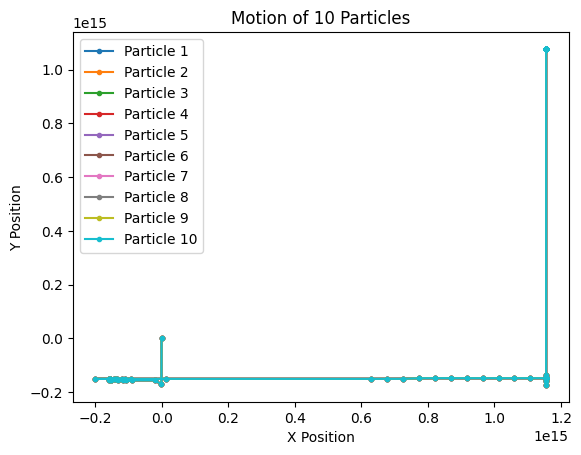

In [93]:
for n in range(10):
    plt.plot(x[:,n], y[:,n],'.-', label=f"Particle {n+1}")
plt.title("Motion of 10 Particles")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()